In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load Data
df = pd.read_csv("../dataset/textile_engineering_dataset.csv")

df.head()

,machine_speed_rpm,temperature_c,humidity_percent,vibration_level,energy_usage_kwh,production_count,defect_count,hours_since_last_maintenance,maintenance_required,alert_triggered,defective_product
0,1549.671415,81.996777,46.284260,0.557313,116.713296,176,5,90,0,0,0
1,1486.173570,79.623168,32.640394,0.321413,124.241867,162,6,80,0,0,1
2,1564.768854,75.298152,43.952821,0.464037,100.132826,129,3,145,0,0,0
3,1652.302986,71.765316,34.439924,0.530111,99.682423,56,5,149,1,0,1
4,1476.584663,78.491117,62.329408,0.518383,92.229149,65,5,60,0,0,0


In [3]:
# 3.6 Split Data (70% Train, 30% Test)
# Nama kolom target yang benar sesuai dataset Anda adalah 'defective_product'
X = df.drop('defective_product', axis=1)
y = df['defective_product']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 700
Jumlah data testing: 300


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("../dataset/textile_engineering_dataset.csv")
print("--- Tampilan 5 Data Teratas ---")
print(df.head())

# 3.3 Struktur Dataset
print("\n--- Struktur Dataset ---")
df.info()

# 3.4 Pengecekan Missing Value
print("\n--- Pengecekan Missing Value ---")
print(df.isnull().sum())

# 3.5 Encoding Data
# Mengubah kolom kategorikal (seperti 'Product_Quality' atau 'Machine_Type') menjadi angka
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("\n--- Data Setelah Encoding ---")
print(df.head())

--- Tampilan 5 Data Teratas ---
   machine_speed_rpm  temperature_c  humidity_percent  vibration_level  \
0        1549.671415      81.996777         46.284260         0.557313   
1        1486.173570      79.623168         32.640394         0.321413   
2        1564.768854      75.298152         43.952821         0.464037   
3        1652.302986      71.765316         34.439924         0.530111   
4        1476.584663      78.491117         62.329408         0.518383   

   energy_usage_kwh  production_count  defect_count  \
0        116.713296               176             5   
1        124.241867               162             6   
2        100.132826               129             3   
3         99.682423                56             5   
4         92.229149                65             5   

   hours_since_last_maintenance  maintenance_required  alert_triggered  \
0                            90                     0                0   
1                            80             

In [6]:
# 3.6 Split Data (70% Train, 30% Test)
# Nama kolom target yang benar sesuai dataset Anda adalah 'defective_product'
X = df.drop('defective_product', axis=1)
y = df['defective_product']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 700
Jumlah data testing: 300


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membangun Model MLP untuk Klasifikasi Biner
mlp_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # 1 neuron dengan sigmoid untuk output 0 atau 1
])

# Menggunakan binary_crossentropy karena ini klasifikasi biner
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Proses Training
history = mlp_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Visualisasi Grafik Akurasi
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy MLP - Textile Production')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

--- Evaluasi KNN ---
              precision    recall  f1-score   support

           0       0.53      0.44      0.48       163
           1       0.45      0.54      0.49       137

    accuracy                           0.48       300
   macro avg       0.49      0.49      0.48       300
weighted avg       0.49      0.48      0.48       300



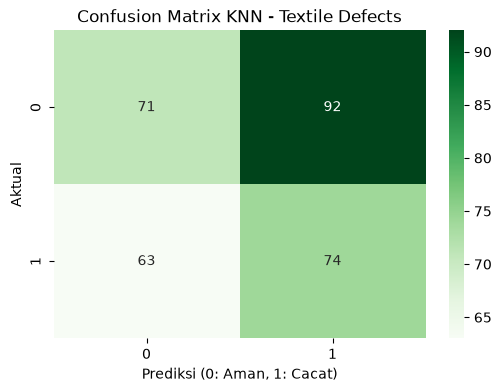

In [8]:
# ==========================================
# 4.1 IMPLEMENTASI & EVALUASI KNN
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi Model
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Training Model (Pastikan X_train dan y_train sudah ada dari tahap split data)
knn_model.fit(X_train, y_train)

# 3. Melakukan Prediksi (INI BAGIAN YANG TADI KURANG/BELUM DIJALANKAN)
y_pred_knn = knn_model.predict(X_test)

# 4. Menampilkan Detail Evaluasi
print("--- Evaluasi KNN ---")
print(classification_report(y_test, y_pred_knn))

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix KNN - Textile Defects')
plt.xlabel('Prediksi (0: Aman, 1: Cacat)')
plt.ylabel('Aktual')
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Menentukan parameter yang akan diuji
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, 
    cv=5, 
    scoring='accuracy'
)
grid_rf.fit(X_train, y_train)

print("--- Hasil Optimasi Random Forest ---")
print("Parameter Terbaik:", grid_rf.best_params_)
print(f"Akurasi Setelah Tuning: {grid_rf.best_score_:.2f}")

--- Hasil Optimasi Random Forest ---
Parameter Terbaik: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Akurasi Setelah Tuning: 1.00


In [13]:
# ==========================================
# 5.1 OPTIMASI MODEL (HYPERPARAMETER TUNING)
# ==========================================
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Menentukan parameter yang akan diuji
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. Inisialisasi GridSearchCV dengan nama class yang benar (tanpa spasi)
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

# 3. Menjalankan Proses Tuning
print("Sedang memproses tuning... Mohon tunggu sebentar.")
grid_rf.fit(X_train, y_train)

# 4. Menampilkan Hasil Terbaik
print("\n--- Hasil Optimasi Random Forest ---")
print("Parameter Terbaik:", grid_rf.best_params_)
print(f"Akurasi Terbaik (Cross-Validation): {grid_rf.best_score_:.4f}")

# 5. Menyimpan hasil prediksi dari model terbaik untuk evaluasi
y_pred_rf_best = grid_rf.best_estimator_.predict(X_test)

Sedang memproses tuning... Mohon tunggu sebentar.

--- Hasil Optimasi Random Forest ---
Parameter Terbaik: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Akurasi Terbaik (Cross-Validation): 1.0000


In [14]:
#Menyimpan Model
import os
import joblib

# Membuat folder model jika belum ada
os.makedirs("../model", exist_ok=True)

# Mengambil model terbaik hasil GridSearchCV
best_rf = grid_rf.best_estimator_

# Menyimpan model
joblib.dump(best_rf, "../model/model.pkl")

print("Model berhasil disimpan di folder model!")

Model berhasil disimpan di folder model!


In [15]:
print(df.columns)

Index(['machine_speed_rpm', 'temperature_c', 'humidity_percent',
       'vibration_level', 'energy_usage_kwh', 'production_count',
       'defect_count', 'hours_since_last_maintenance', 'maintenance_required',
       'alert_triggered', 'defective_product'],
      dtype='str')


In [16]:
df.columns.tolist()

['machine_speed_rpm',
 'temperature_c',
 'humidity_percent',
 'vibration_level',
 'energy_usage_kwh',
 'production_count',
 'defect_count',
 'hours_since_last_maintenance',
 'maintenance_required',
 'alert_triggered',
 'defective_product']